In [1]:
import pathlib, numpy, netCDF4, cartopy
import numpy as np
from matplotlib import pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.tri as mtri

In [2]:
import importlib
import plot_settings
importlib.reload(plot_settings)
plot_settings.load_rcParams()

In [3]:
#home = str(pathlib.Path.home())
grid_filename = '/home/jakobnormal/Documents/hiwi_stelle/data_and_scripts/LIG.kepler/remapped_r2b4/gridfiles/icon_grid_0012_R02B04_G.nc'
data_filename = '/home/jakobnormal/Documents/hiwi_stelle/data_and_scripts/LIG.kepler/remapped_r2b4/LIG.kepler_atm2d_merged.nc'

In [4]:
ds = netCDF4.Dataset(grid_filename)
cx = numpy.degrees(numpy.asarray(ds["clon"]))
cy = numpy.degrees(numpy.asarray(ds["clat"]))

In [5]:
ds = netCDF4.Dataset(data_filename)
src_data = numpy.asarray(ds["t_2m"])[0,0,:]

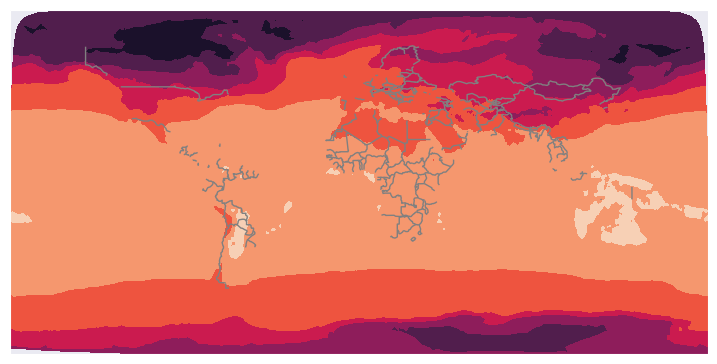

In [7]:
fig = plt.figure(figsize=(9, 9))
ax = plt.axes(projection=cartopy.crs.PlateCarree())
ax.add_feature(cartopy.feature.BORDERS,edgecolor='gray')
ax.tricontourf(cx, cy, src_data, transform=cartopy.crs.PlateCarree())
plt.show()
#fig.savefig("HSURF.png", dpi=200)

In [8]:
ds['t_2m']

<class 'netCDF4._netCDF4.Variable'>
float32 t_2m(time, height_2, ncells)
    standard_name: t_2m
    long_name: temperature in 2m
    units: K
    param: 0.0.0
    CDI_grid_type: unstructured
    number_of_grid_in_reference: 1
    coordinates: clat clon
unlimited dimensions: time
current shape = (3648, 1, 20480)
filling on, default _FillValue of 9.969209968386869e+36 used

# Making a nicer plot in the stile of earlier plots with rectangular lattice:

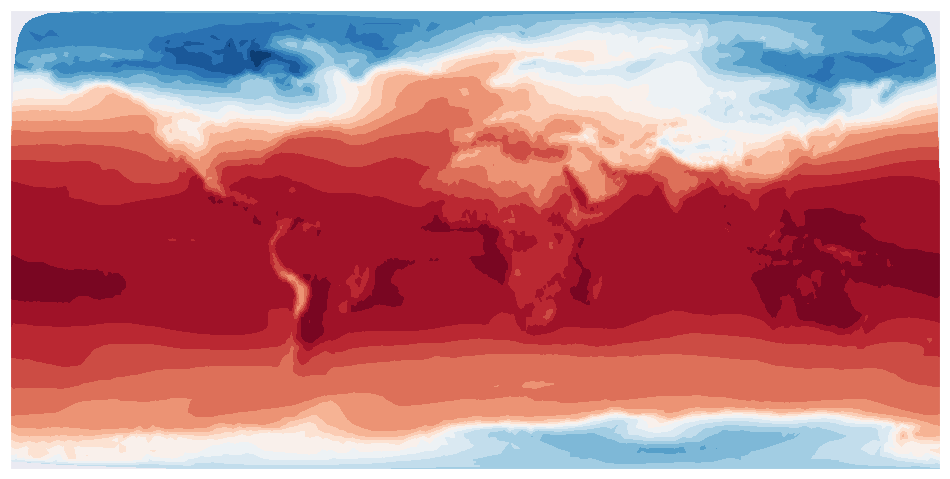

In [9]:
fig, ax = plt.subplots(
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}  # <-- change this
)
triang = mtri.Triangulation(cx, cy)
levels = np.linspace(211, 304, 21)
cf = ax.tricontourf(
    triang, src_data,
    levels=levels,
    cmap="RdBu_r",
    # NO transform argument
    extend="both"
)

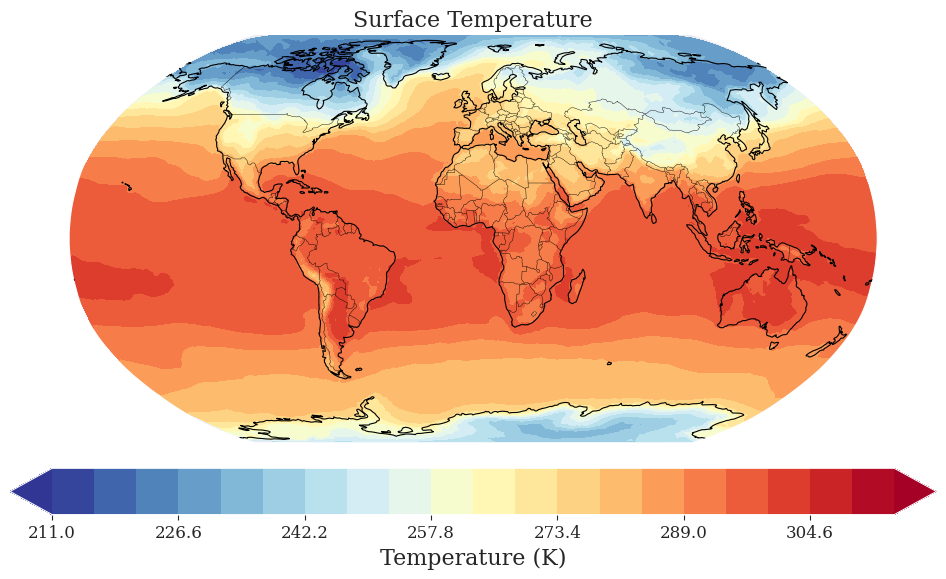

In [10]:
# Reproject points to Robinson before triangulating
rob = ccrs.Robinson()
plate = ccrs.PlateCarree()

# Transform all points to Robinson coordinates
xyz = rob.transform_points(plate, cx, cy)  # shape (N, 3)
cx_rob = xyz[:, 0]
cy_rob = xyz[:, 1]

# Rebuild triangulation in Robinson space
triang_rob = mtri.Triangulation(cx_rob, cy_rob)

# Mask bad triangles (now in metres, threshold ~1e7 m)
x_tri = cx_rob[triang_rob.triangles]
lon_tri = cx[triang_rob.triangles]   # still use original lon for antimeridian mask
lon_min = lon_tri.min(axis=1)
lon_max = lon_tri.max(axis=1)
triang_rob.set_mask(lon_max - lon_min > 180)

# Plot WITHOUT transform (data already in Robinson coords)
fig, ax = plt.subplots(
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.Robinson()}
)

cf = ax.tricontourf(
    triang_rob, src_data,
    levels=np.linspace(211, 315, 21),
    cmap="RdYlBu_r",
    extend="both"
    # NO transform
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=5)
ax.add_feature(cfeature.BORDERS,   linewidth=0.3, zorder=5)
cbar = plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8)
cbar.set_label("Temperature (K)")
plt.title("Surface Temperature")
plt.tight_layout()
plt.savefig('figs/temperature_first_tricontourfplot.png', dpi=200)

In [11]:

src_data_annual = numpy.asarray(ds["t_2m"])[0,0,:]
src_data_jul = numpy.asarray(ds["t_2m"])[200,0,:]
src_data_jan = numpy.asarray(ds["t_2m"])[1250,0,:]
ylims = [210, 310]

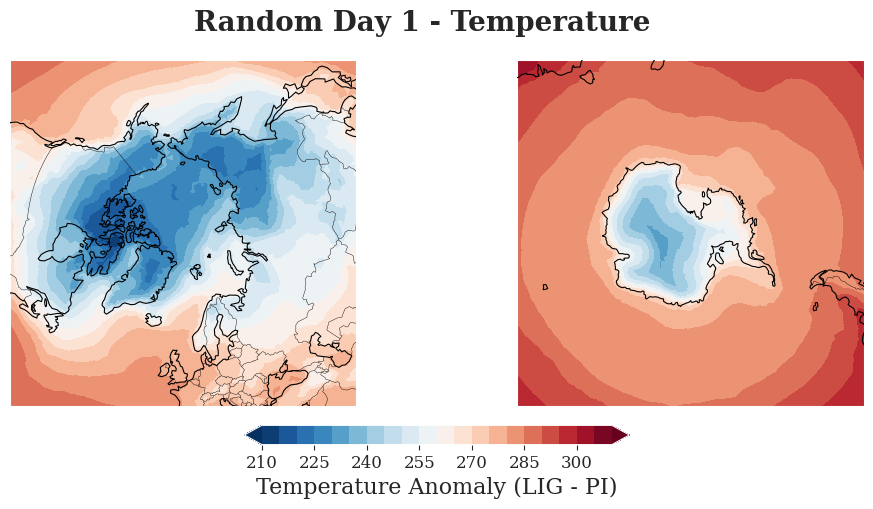

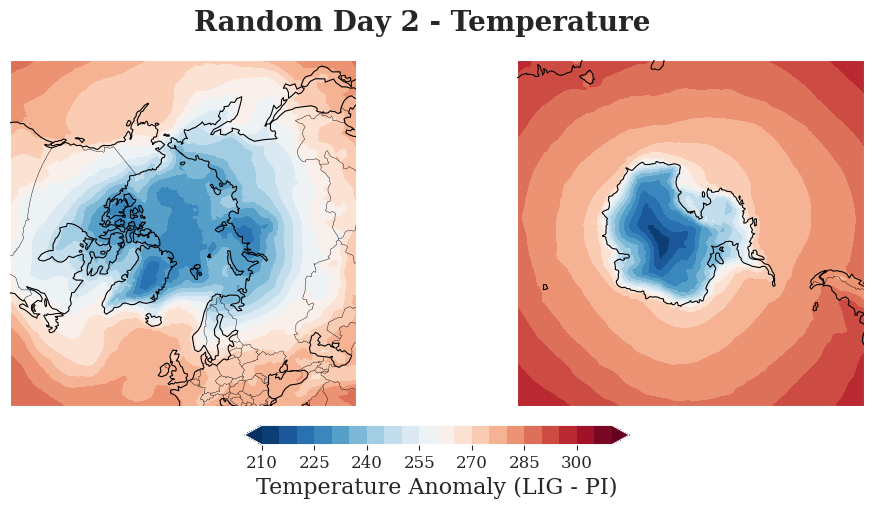

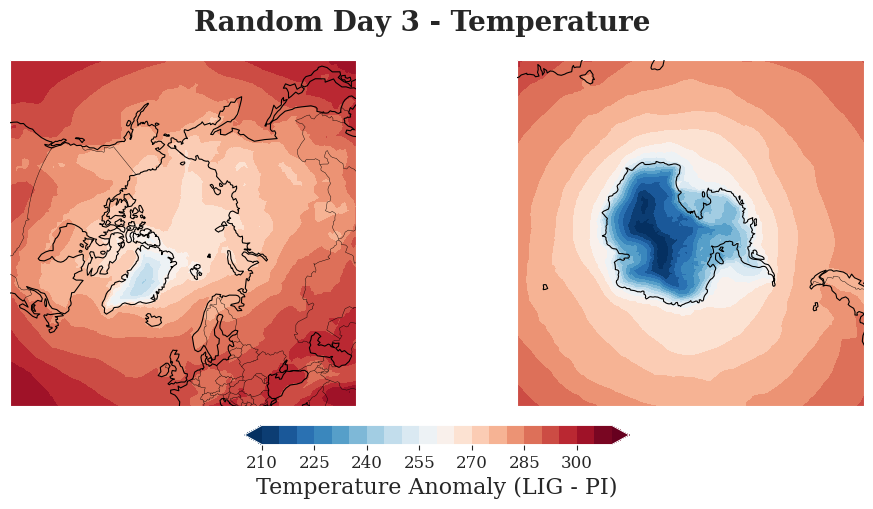

In [12]:
def make_triang_for_projection(projection, cx, cy):
    plate = ccrs.PlateCarree()
    xyz = projection.transform_points(plate, cx, cy)
    cx_proj = xyz[:, 0]
    cy_proj = xyz[:, 1]

    triang_proj = mtri.Triangulation(cx_proj, cy_proj)

    # Compute the size of each triangle in projected coordinates
    triangles = triang_proj.triangles
    x_tri = cx_proj[triangles]  # shape (n_tri, 3)
    y_tri = cy_proj[triangles]

    # Mask triangles that are huge in projection space (wrap-around artifacts)
    # Threshold: triangles wider/taller than 10% of the total projected extent
    x_extent = np.nanmax(cx_proj) - np.nanmin(cx_proj)
    y_extent = np.nanmax(cy_proj) - np.nanmin(cy_proj)

    x_span = x_tri.max(axis=1) - x_tri.min(axis=1)
    y_span = y_tri.max(axis=1) - y_tri.min(axis=1)

    bad = (x_span > 0.1 * x_extent) | (y_span > 0.1 * y_extent)
    triang_proj.set_mask(bad)

    return triang_proj


datasets = [
    (src_data_annual, "Random Day 1"),
    (src_data_jan,    "Random Day 2"),
    (src_data_jul,    "Random Day 3"),
]

vmin, vmax = ylims[0], ylims[1]
cmap = "RdBu_r"
levels = np.linspace(vmin, vmax, 21)

for src_data, label in datasets:

    proj_n = ccrs.NorthPolarStereo()
    proj_s = ccrs.SouthPolarStereo(central_longitude=180)

    triang_n = make_triang_for_projection(proj_n, cx, cy)
    triang_s = make_triang_for_projection(proj_s, cx, cy)

    fig = plt.figure(figsize=(12, 5))

    # --- Northern Hemisphere ---
    ax_n = fig.add_subplot(1, 2, 1, projection=proj_n)
    cf = ax_n.tricontourf(
        triang_n, src_data,
        levels=levels,
        cmap=cmap,
        extend="both"
        # NO transform
    )
    ax_n.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black", zorder=5)
    ax_n.add_feature(cfeature.BORDERS,   linewidth=0.3, zorder=5)
    ax_n.set_extent([-180, 180, 45, 90], crs=ccrs.PlateCarree())
    ax_n.set_title("")

    # --- Southern Hemisphere ---
    ax_s = fig.add_subplot(1, 2, 2, projection=proj_s)
    ax_s.tricontourf(
        triang_s, src_data,
        levels=levels,
        cmap=cmap,
        extend="both"
        # NO transform
    )
    ax_s.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="black", zorder=5)
    ax_s.add_feature(cfeature.BORDERS,   linewidth=0.3, zorder=5)
    ax_s.set_extent([-180, 180, -90, -45], crs=ccrs.PlateCarree())
    ax_s.set_title("")

    # --- Shared colorbar ---
    cbar = fig.colorbar(cf, ax=[ax_n, ax_s], orientation="horizontal",
                        fraction=0.05, pad=0.05, shrink=0.6)
    cbar.set_label("Temperature Anomaly (LIG - PI)")

    fig.suptitle(f"{label} - Temperature",
                 fontsize=20, fontweight="bold")

    #plt.tight_layout()
    plt.savefig(f'figs/temperature_poles_at_{label}.png', dpi=200)
    plt.show()